In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange
from astropy.cosmology import Planck18

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


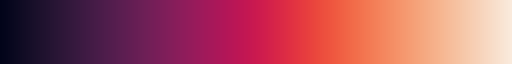

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [10]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_88045/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_88045/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


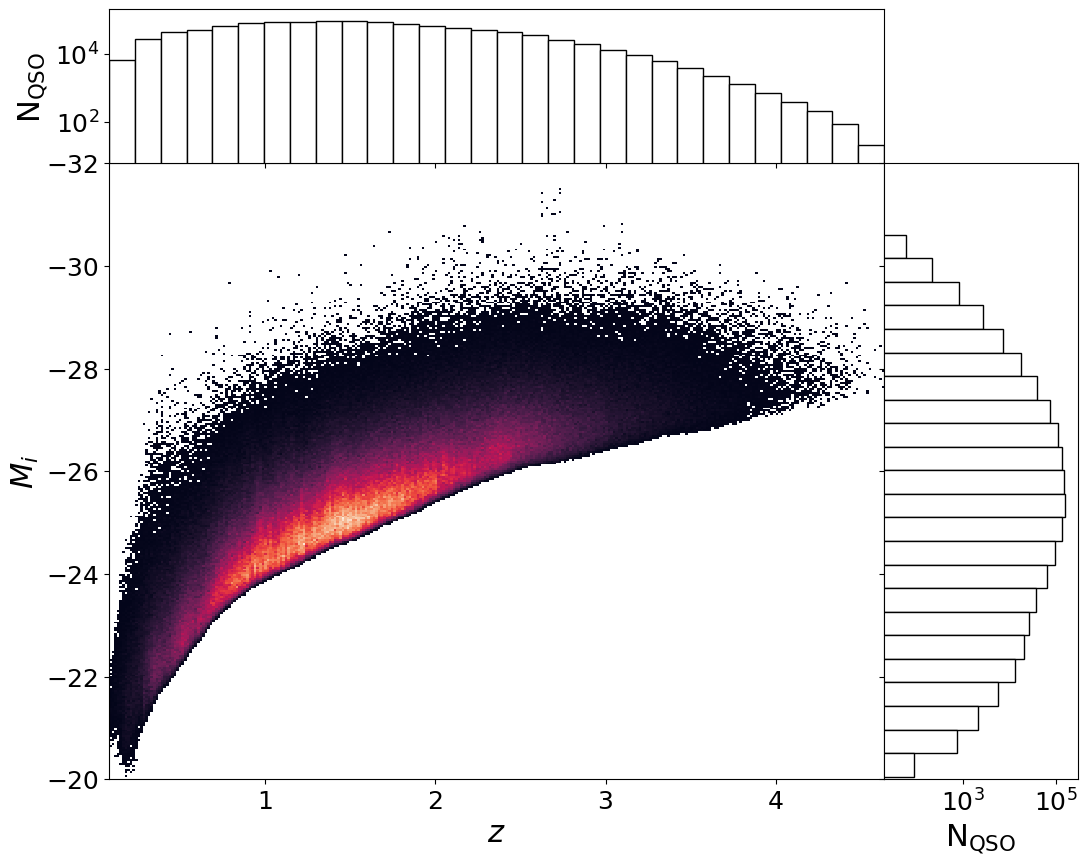

In [11]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in joint bins
## $\xi(s)$

In [12]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
sbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [13]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

In [14]:
# h = 0.674
# Omega_m_planck20 = 0.315
# h = Planck18.h
# Omega_m_planck20 = Planck18.Om0

In [15]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
L_array = range(len(L_bins)-1)
z_array = range(len(z_bins)-1)
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
# tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [20.0, 20.5]
L_labels = ['${}<M_i\leq{}$'.format(L_bins[L], L_bins[L+1]) for L in range(len(L_bins[:-1]))]
z_labels = ['${}<z\leq{}$'.format(z_bins[L], z_bins[L+1]) for L in range(len(z_bins[:-1]))]
mask = 0.5

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_88045/4114594187.py:10: SyntaxWarning: invalid escape sequence '\l'
  L_labels = ['${}<M_i\leq{}$'.format(L_bins[L], L_bins[L+1]) for L in range(len(L_bins[:-1]))]
/tmp/ipykernel_88045/4114594187.py:11: SyntaxWarning: invalid escape sequence '\l'
  z_labels = ['${}<z\leq{}$'.format(z_bins[L], z_bins[L+1]) for L in range(len(z_bins[:-1]))]


<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:80: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_88045/2016180290.py:55: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_88045/2016180290.py:80: SyntaxWarning: invalid escape sequence '\l'
  ax1.legend(loc = 'center right', bbox_to_anchor = (-0.15, 0.5), title = '${}<M_i\leq{}$'.format(L_bins[k], L_bins[k+1]), title_fontsize = 18)
/tmp/ipykernel_88045/2016180290.py:86: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


G20.5_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.32              1265 vs 1860
1265
26937


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.36              24505 vs 38015
24505
577733


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


...

G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.27              196983 vs 270122
196983
4801912


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0: 0.14              128742 vs 149321
128742
2944901


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


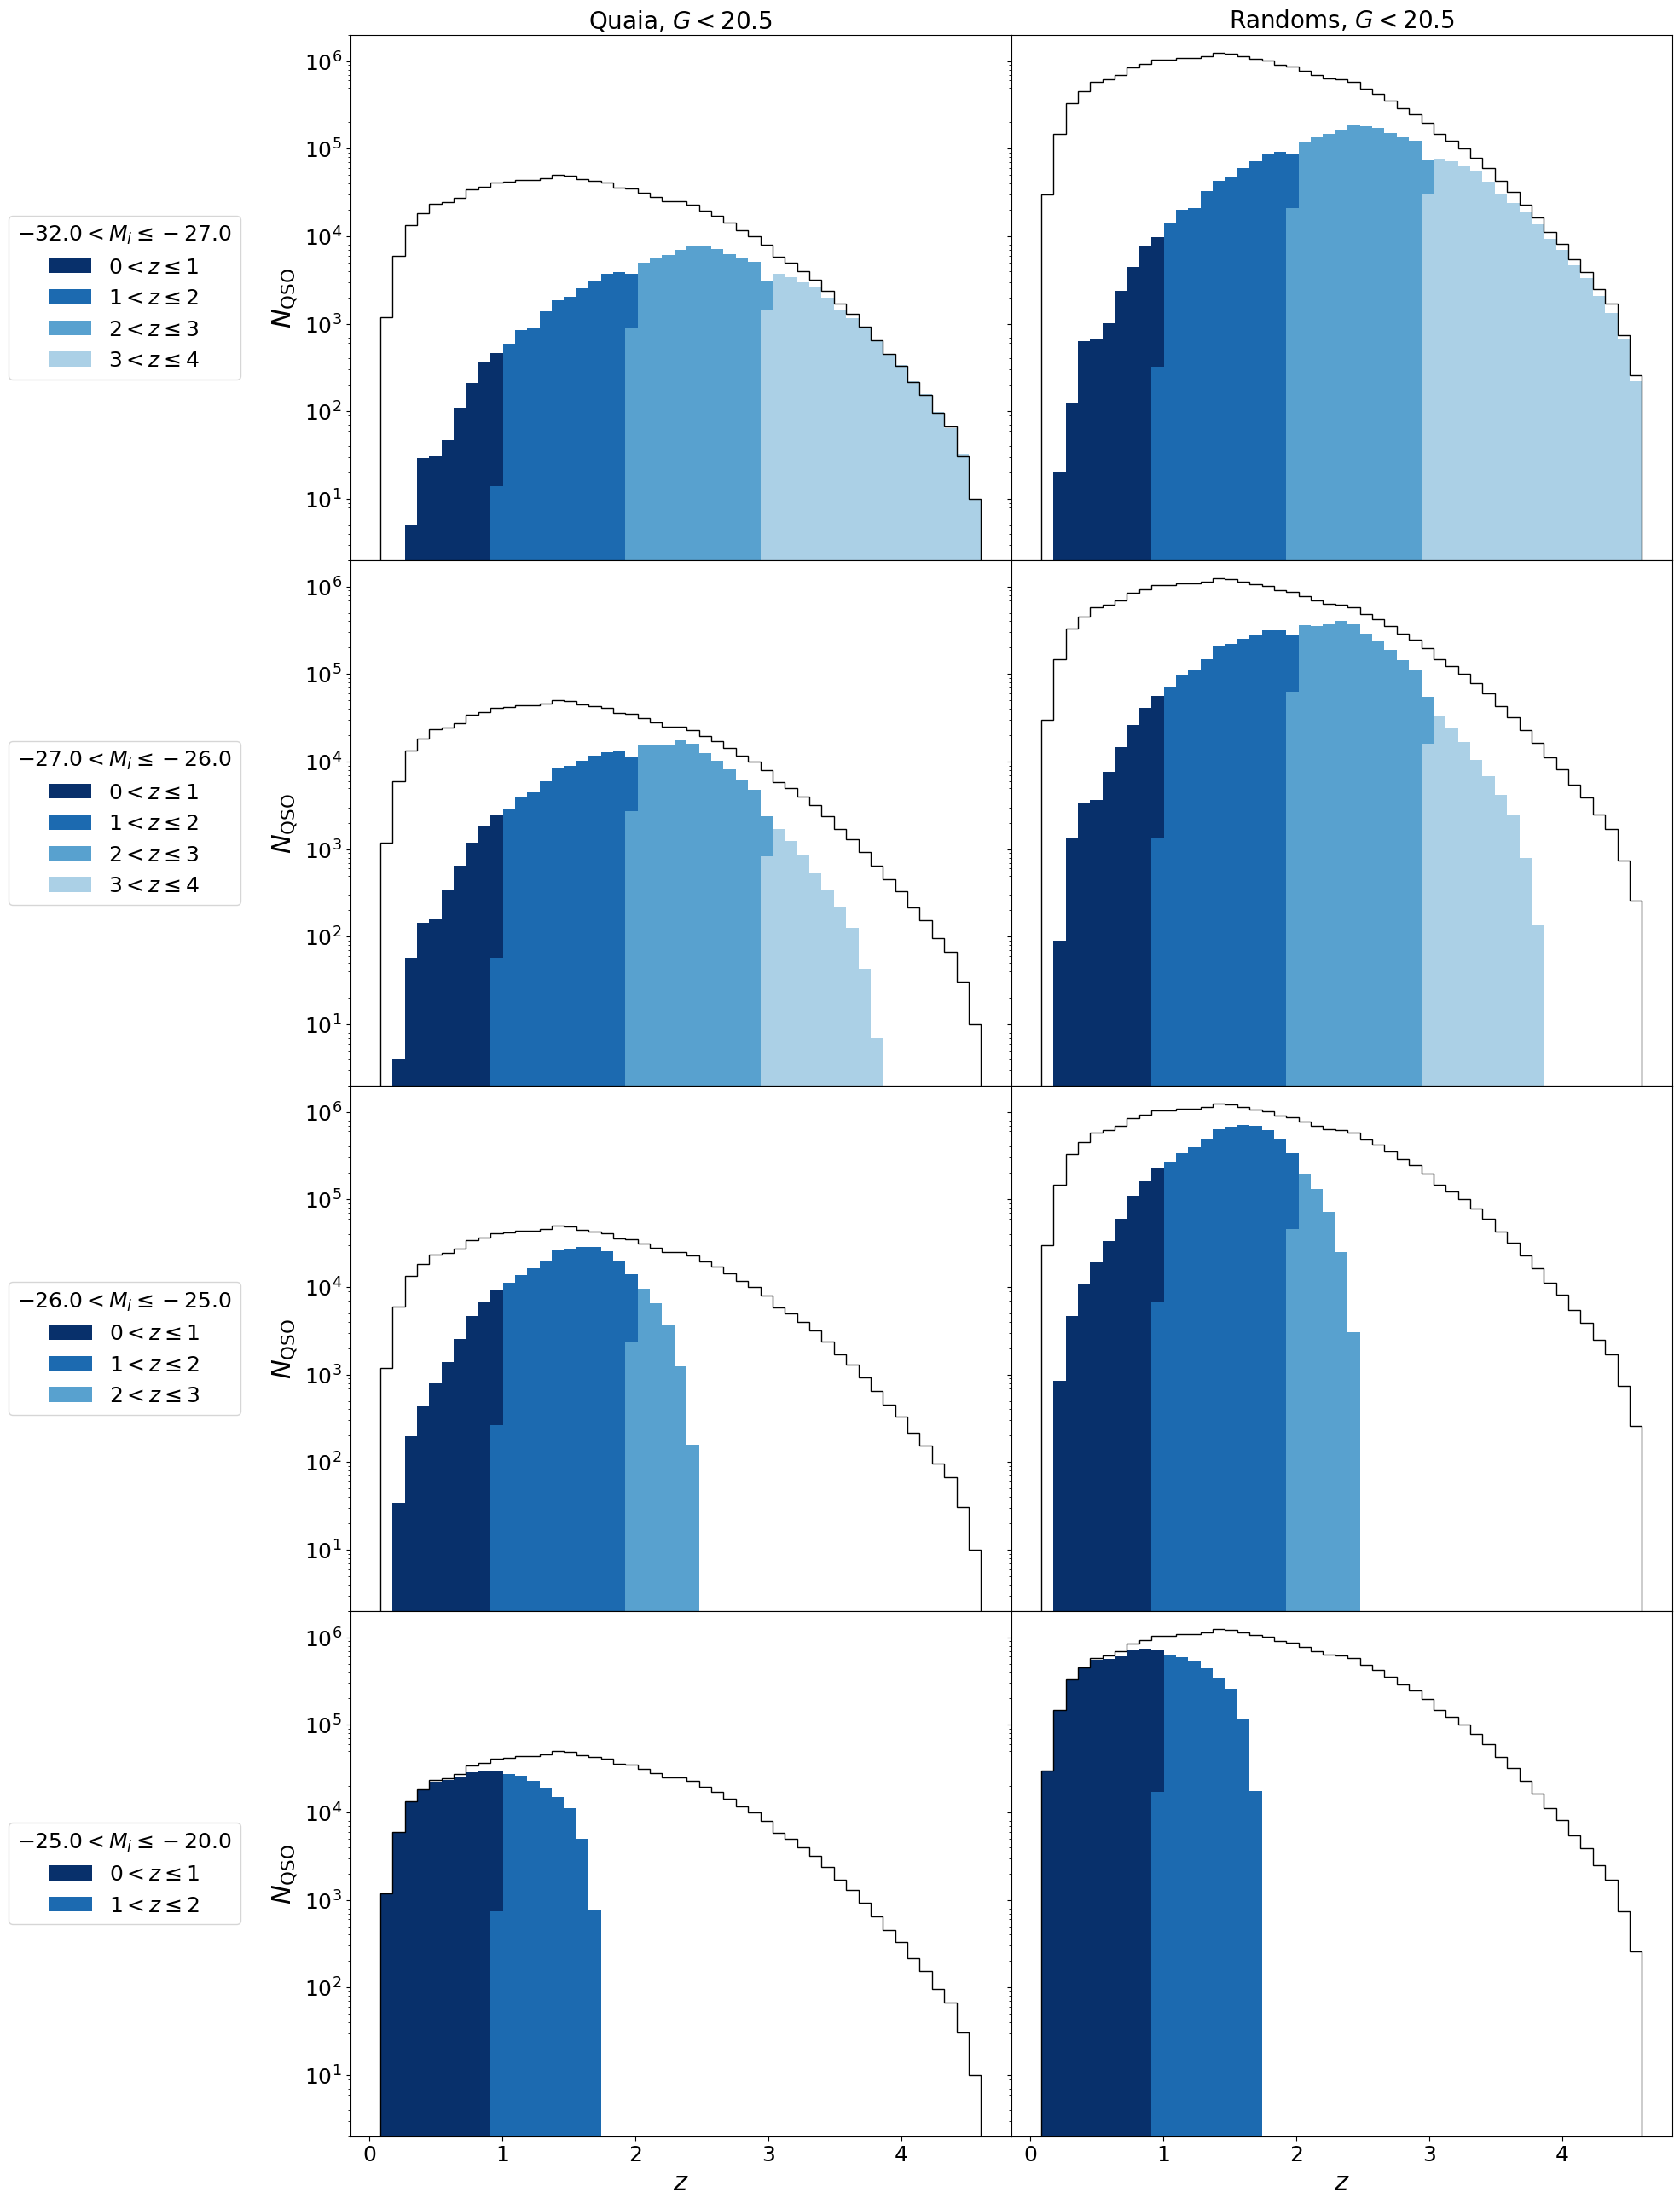

In [16]:
# plot data
locs = ['center right', 'center left']
x = [-0.15, 1]
bins = np.linspace(0.08, 4.6)
cf = []
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

# ax1 = fig.add_subplot(gs[0])
# ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
# ax2 = fig.add_subplot(gs[1])

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
# ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
#          color = 'black')

for k in L_array:

    ax1 = fig.add_subplot(gs[k*2])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')
        
    ax2 = fig.add_subplot(gs[k*2+1])
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], bins=bins, histtype = 'step', color='black')
        
    cf_L = []
    
    for j in z_array:
        try:
            tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j,k], True, ['z', 'L'], 
                                                                                                 bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                 method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                 n_bins = [None, None], mask = mask*100, 
                                                                                                 percentile = True)
            
            ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
             bins = bins, color = cmap_blue[j])
            ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(j),
             bins = bins, color = cmap_blue[j])
            print(len(tab_datahi_mask_zbin0))
            print(len(tab_randhi_mask_zbin0))
    
            cf_L = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = sbins, h = Planck18.h, 
                                 Om0 = Planck18.Om0)
        except:
            print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                  L_bins[k+1]))
    cf.append(cf_L)

    if k == 0:
        ax1.set_title('Quaia, $G<{}$'.format(G_hi))
        ax2.set_title('Randoms, $G<{}$'.format(G_hi))
    if k == 3:
        ax1.set_xlabel('$z$')
        ax2.set_xlabel('$z$')
    else:
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])
    ax1.set_yscale('log')
    ax2.set_yscale('log')
    ax1.legend(loc = 'center right', bbox_to_anchor = (-0.15, 0.5), title = '${}<M_i\leq{}$'.format(L_bins[k], L_bins[k+1]), title_fontsize = 18)
    ax1.set_ylim(2, 2e6)
    ax2.set_ylim(2, 2e6)
    # if i>0:
    ax2.set_yticklabels([])
    # else:
    ax1.set_ylabel('$N_\mathrm{QSO}$')
    
plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [17]:
N = 25 #10
ra_bins = np.linspace(0, 360, N+1)
# N = len(ra_bins)
for i in range(N): #-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 1

## Compute $\xi(s)$ in each jackknife bin

In [18]:
cf_jackknife = {k: [] for k in L_array}

for k in L_array:
    
    cf_L = []

    for j in z_array:
        try:
            tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j,k], True, ['z', 'L'], 
                                                                                                 bins = [z_bins, L_bins], tab_gcat_type = 'data',
                                                                                                 method = ['minmax', 'minmax'], fac_rand = 25,
                                                                                                 n_bins = [None, None], mask = mask*100, 
                                                                                                 percentile = True)
            
            for i in trange(N): #len(ra_bins)-1):
    
                jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
                jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

                cf_L.append(quaia.xi_s(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                                 nthreads = nthreads, rbins = sbins, h = Planck18.h, Om0 = Planck18.Om0))
        except:
            print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                  L_bins[k+1]))
    cf_jackknife[k].append(cf_L)

G20.5_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0: 0.32              1265 vs 1860


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [00:05<00:00,  4.75it/s]


G20.5_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0: 0.36              24505 vs 38015


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [00:57<00:00,  2.29s/it]


G20.5_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0: 0.34              67014 vs 102196


...

G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-25.0Lmax-20.0: 0.27              196983 vs 270122


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [13:04<00:00, 31.38s/it]


G20.5_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0: 0.14              128742 vs 149321


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [06:13<00:00, 14.94s/it]

G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25.0Lmax-20.0:                   no selection function


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [19]:
C = {k: [] for k in L_array}

for k in L_array:
    
    C_L = []
    for zbin in zbin_array[:-1]:
        
        try:
            cf_mean = np.nanmean(cf_jackknife[k][int(zbin)], axis = 0)  # is it ok to ignore nan values?
            delta = cf_jackknife[k][int(zbin)]-cf_mean
            C_L = (N-1)/N*(delta.T @ delta)
        except:
            print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, zbin, zbin+1, L_bins[k], 
                                                                                                  L_bins[k+1]))
    C[k].append(C_L)

G20.5_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-25.0Lmax-20.0:                   no selection function


/tmp/ipykernel_88045/374070818.py:9: RuntimeWarning: Mean of empty slice
  cf_mean = np.nanmean(cf_jackknife[k][int(zbin)], axis = 0)  # is it ok to ignore nan values?


## Save the full covariance matrix

In [20]:
for k in L_array:
    
    for zbin in zbin_array[:-1]:
        
        try:
    
            np.save('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmin{}Lmax{}_N{}_planck20'.format(G_hi, rmin, rmax, nbins, zbin, zbin+1,
                                                                                                            L_bins[k], L_bins[k+1], N), 
                    C[k][int(zbin)])
        except:
            print('G{}_zmin{:.1f}zmax{:.1f}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, zbin, zbin+1, L_bins[k], 
                                                                                                  L_bins[k+1]))

G20.5_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-25.0Lmax-20.0:                   no selection function
G20.5_zmin3.0zmax4.0_Lmin-25.0Lmax-20.0:                   no selection function


# Plot

G20.5_zmin0.0zmax1.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin1.0zmax2.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin2.0zmax3.0_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin0.0zmax1.0_Lmin-25

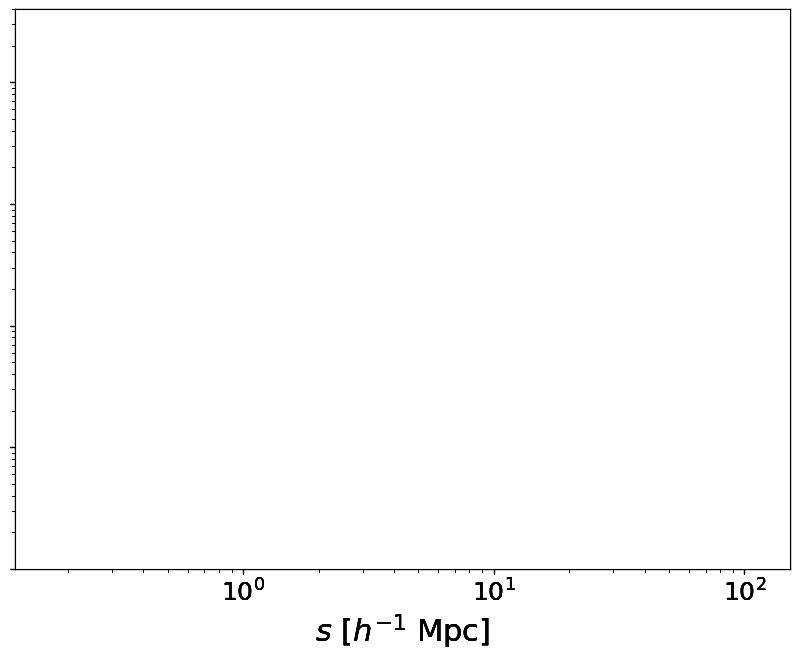

In [21]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)

# for i in range(len(G_array)):
    
for k in L_array:
    
    ax1 = fig.add_subplot(gs[j])
    
    for j in z_array:
        
        try:
            sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmin{}Lmax{}_N{}_planck20.npy'.format(G_hi,
                                                                                                                                            rmin, 
                                                                                                                                            rmax, 
                                                                                                                            nbins, zbin, zbin+1,
                                                                                                        L_bins[k], L_bins[k+1], N))))
            ax1.errorbar(quaia.recenter(sbins), cf[k][j], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmap_blue[k], yerr = sigma)
        except:
            print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                  L_bins[k+1]))
    
    if j == 0:
        ax1.set_title(z_labels[j])
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
    ax1.set_ylim(1e-3, 4e1)
    # ax1.legend(title = z_labels[j], title_fontsize = 18)
    if i==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    # if j == 3:
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax1.set_xticklabels([])

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_88045/157523915.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))


G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-32.0Lmax-27.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-27.0Lmax-26.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-26.0Lmax-25.0:                   no selection function
G20.5_zmin3.0zmax4.6_Lmin-25

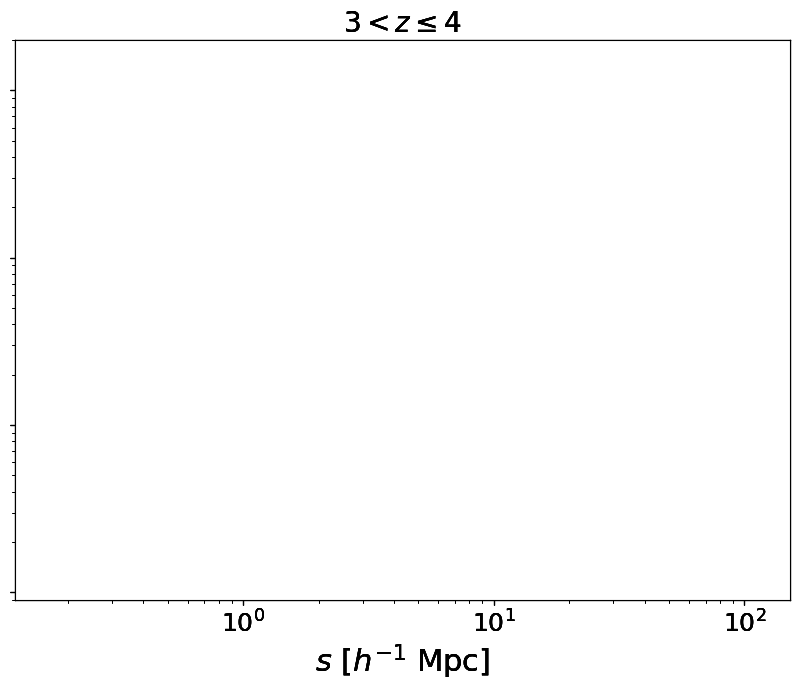

In [22]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)

for k in L_array:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    for zbin in zbin_array[:-1]:
    
        try:
        
            sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}_planck20.npy'.format(G_hi, rmin, rmax, nbins, zbin, 
                                                                                                                      N))))    
            ax1.errorbar(quaia.recenter(sbins), cf[k][j], label = L_labels[k], linewidth = 2.5, marker = 'o', color = cmap_blue[k], yerr = sigma)
        except:
                print('G{}_zmin{}zmax{}_Lmin{}Lmax{}:                   no selection function'.format(G_hi, z_bins[j], z_bins[j+1], L_bins[k], 
                                                                                                      L_bins[k+1]))
        
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(sbins)[0], quaia.recenter(sbins)[-1])
    ax1.set_ylim(9e-4, 2)
    # if zbin>1:
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax1.set_xticklabels([])
    if zbin%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    # ax1.legend()

plt.show()